In [6]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import json

# import all json files
with open("eval_results/evaluation_metrics_bert.json", "r") as f:
    bert_metrics = json.load(f)

with open("eval_results/evaluation_metrics_dictionary.json", "r") as f:
    dictionary_metrics = json.load(f)

with open("eval_results/evaluation_metrics_bert_nli.json", "r") as f:
    nli_metrics = json.load(f)

# combine all models
all_metrics = {**bert_metrics, **dictionary_metrics, **nli_metrics}

# adapt the dictionary baseline
all_metrics["dictionary_baseline"] = {
    "negative_f1": all_metrics["dictionary_baseline"]["negative"]["neg"],
    "neutral_f1": all_metrics["dictionary_baseline"]["neutral"]["neutral"],
    "positive_f1": all_metrics["dictionary_baseline"]["positive"]["pos"],
    "macro_f1": (
        all_metrics["dictionary_baseline"]["negative"]["neg"]+
        all_metrics["dictionary_baseline"]["neutral"]["neutral"]+
        all_metrics["dictionary_baseline"]["positive"]["pos"]
    )/3,
    }

# reorder the dictionary
all_metrics = dict(
    (k, all_metrics[k]) for k in [
        'NLI_deberta',
        'microsoft/deberta-v3-base',
        'roberta-base',
        'bert-base-cased',
        'distilbert-base-cased',
        'dictionary_baseline'
    ]
)

In [14]:
all_metrics

{'NLI_deberta': {'negative_f1': 0.7500000000000001,
  'neutral_f1': 0.6900000000000001,
  'positive_f1': 0.855530474040632,
  'macro_f1': 0.7651768246802106},
 'microsoft/deberta-v3-base': {'negative_f1': 0.6530612244897959,
  'neutral_f1': 0.5302013422818792,
  'positive_f1': 0.8554336989032901,
  'macro_f1': 0.679565421891655},
 'roberta-base': {'negative_f1': 0.6774193548387096,
  'neutral_f1': 0.6062322946175638,
  'positive_f1': 0.853475935828877,
  'macro_f1': 0.7123758617617169},
 'bert-base-cased': {'negative_f1': 0.5652173913043478,
  'neutral_f1': 0.5584045584045584,
  'positive_f1': 0.8352570828961176,
  'macro_f1': 0.6529596775350078},
 'dictionary_baseline': {'negative_f1': 0.166666666666667,
  'neutral_f1': 0.384207992296582,
  'positive_f1': 0.569657774184856,
  'macro_f1': 0.3735108110493683}}

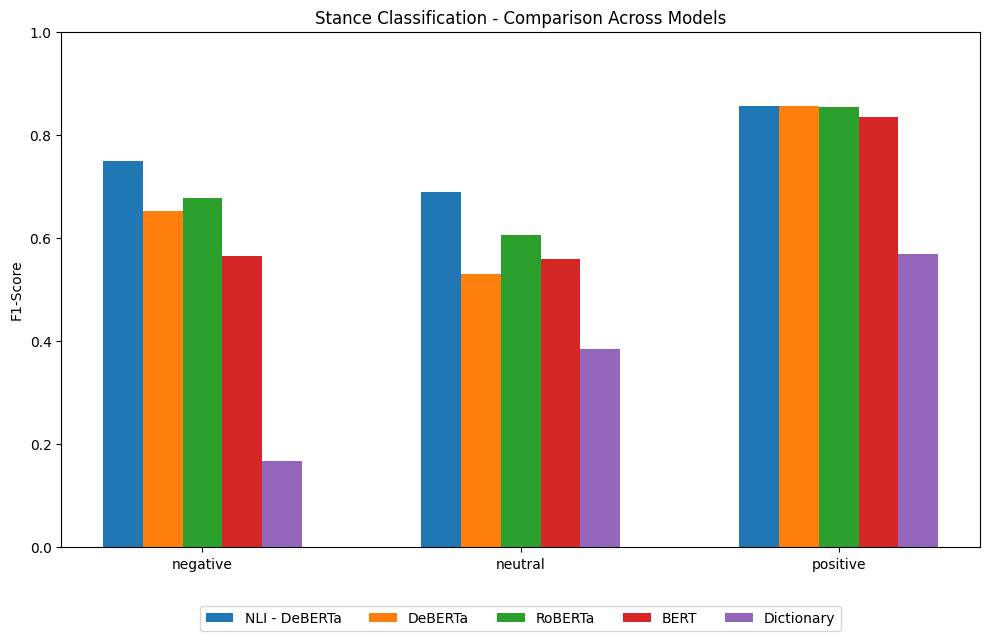

In [16]:
models = list(all_metrics.keys())
metrics = ['negative_f1', 'neutral_f1', 'positive_f1']
values = np.array([[all_metrics[m][metric] for metric in metrics] for m in models])
model_labels = ["NLI - DeBERTa", "DeBERTa", "RoBERTa", "BERT",  "Dictionary"]

# create the plot
x = np.arange(len(metrics))
width = 0.125
fig, ax = plt.subplots(figsize=(10, 6.5))
for i, model in enumerate(models):
    ax.bar(x + i*width, values[i], width, label=model_labels[i])
ax.set_xticks(x + width*(len(models)-1)/2)
ax.set_xticklabels(["negative", "neutral", "positive"])
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1)
ax.set_title('Stance Classification - Comparison Across Models')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=len(models))
plt.tight_layout()
plt.show()